In [1]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

cp: cannot stat 'kaggle.json': No such file or directory


In [2]:
!kaggle datasets download -d santoshd3/bank-customers
!kaggle datasets download -d ckay16/accident-detection-from-cctv-footage

Dataset URL: https://www.kaggle.com/datasets/santoshd3/bank-customers
License(s): other
bank-customers.zip: Skipping, found more recently modified local copy (use --force to force download)
Dataset URL: https://www.kaggle.com/datasets/ckay16/accident-detection-from-cctv-footage
License(s): ODbL-1.0
Resuming from 1048576 bytes (260463347 bytes left)...
100% 249M/249M [00:14<00:00, 18.5MB/s]



In [3]:
!unzip -o bank-customers.zip

Archive:  bank-customers.zip
  inflating: Churn Modeling.csv      


In [4]:
!ls

 accident-detection-from-cctv-footage.zip  'Churn Modeling.csv'
 bank-customers.zip			    sample_data


In [5]:
# Install Keras Tuner
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 12.0 MB/s eta 0:00:00


In [6]:
# Core libraries
import os
import zipfile
import random
import cv2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf


# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# TensorFlow / Keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Hyperparameter tuning
import keras_tuner as kt

In [7]:
df = pd.read_csv("Churn Modeling.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [8]:
df.shape

(10000, 14)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [10]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [11]:
df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df["Exited"].value_counts()

,count
Exited,
0,7963
1,2037


In [14]:
# Normalized churn rate by gender
gender_churn = pd.crosstab(df["Gender"], df["Exited"], normalize="index") * 100
print(gender_churn)

Exited          0          1
Gender                      
Female  74.928461  25.071539
Male    83.544072  16.455928


In [15]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


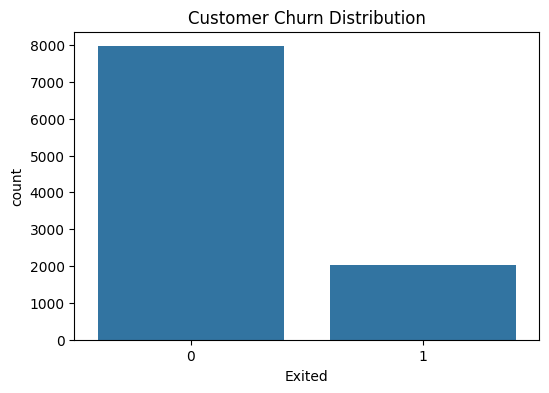

In [16]:
plt.figure(figsize=(6,4))
sns.countplot(x="Exited", data=df)
plt.title("Customer Churn Distribution")
plt.show()

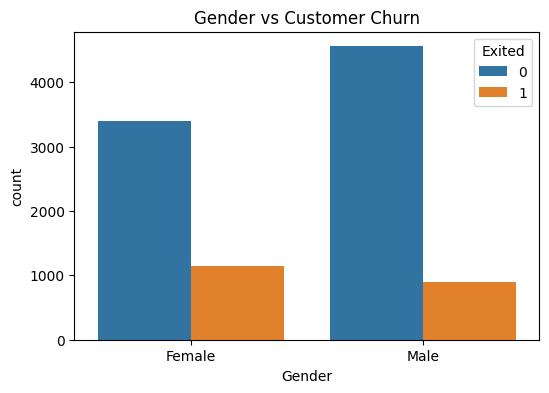

In [17]:
plt.figure(figsize=(6,4))
sns.countplot(x="Gender", hue="Exited", data=df)
plt.title("Gender vs Customer Churn")
plt.show()

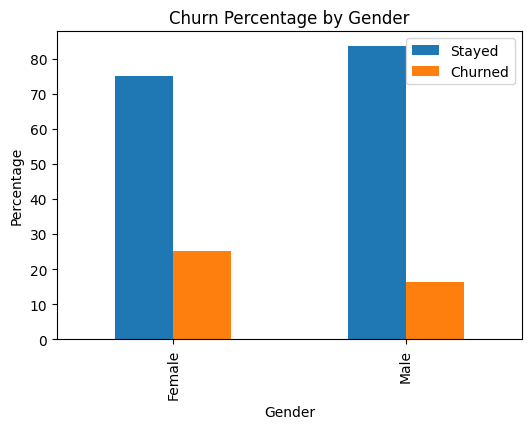

In [18]:
gender_churn.plot(kind="bar", figsize=(6,4))
plt.title("Churn Percentage by Gender")
plt.ylabel("Percentage")
plt.xlabel("Gender")
plt.legend(["Stayed", "Churned"])
plt.show()

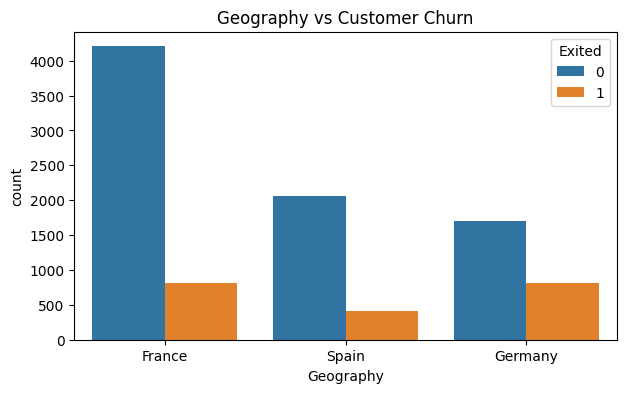

In [19]:
plt.figure(figsize=(7,4))
sns.countplot(x="Geography", hue="Exited", data=df)
plt.title("Geography vs Customer Churn")
plt.show()

In [20]:
# Normalized churn percentage by geography
geo_churn = pd.crosstab(df["Geography"], df["Exited"], normalize="index") * 100
print(geo_churn)

Exited             0          1
Geography                      
France     83.845233  16.154767
Germany    67.556796  32.443204
Spain      83.326605  16.673395


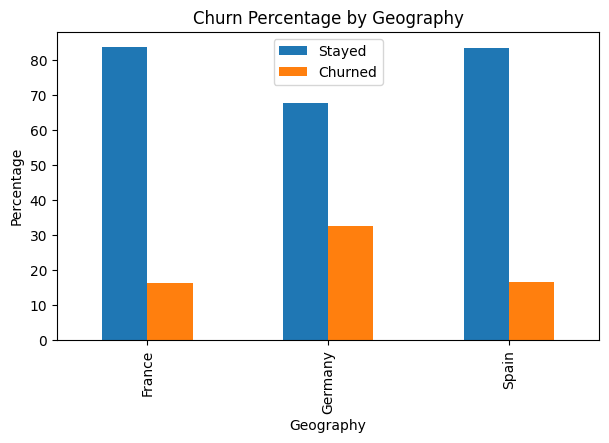

In [21]:
geo_churn.plot(kind="bar", figsize=(7,4))
plt.title("Churn Percentage by Geography")
plt.ylabel("Percentage")
plt.xlabel("Geography")
plt.legend(["Stayed", "Churned"])
plt.show()

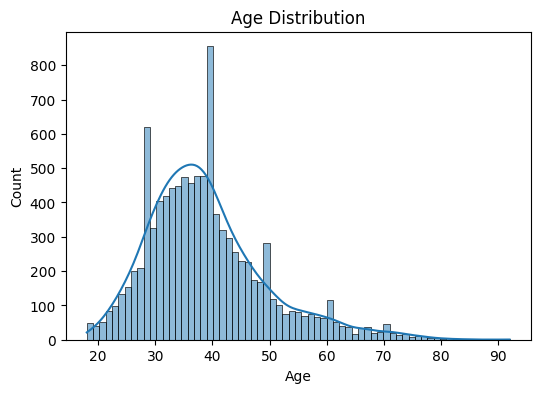

In [22]:
plt.figure(figsize=(6,4))
sns.histplot(df["Age"], kde=True)
plt.title("Age Distribution")
plt.show()

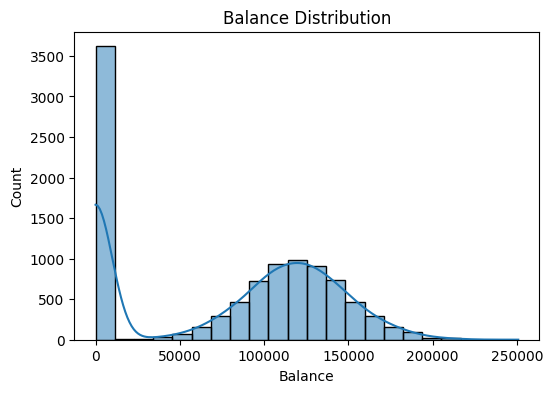

In [23]:
plt.figure(figsize=(6,4))
sns.histplot(df["Balance"], kde=True)
plt.title("Balance Distribution")
plt.show()

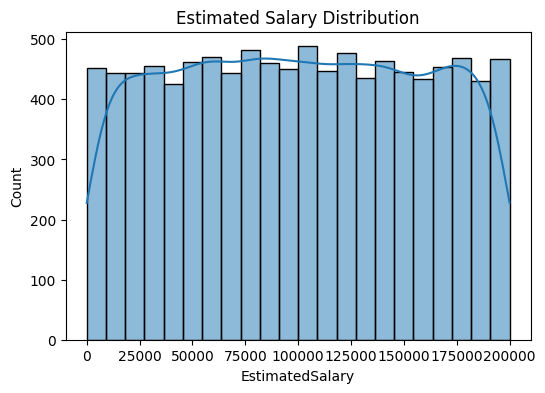

In [24]:
plt.figure(figsize=(6,4))
sns.histplot(df["EstimatedSalary"], kde=True)
plt.title("Estimated Salary Distribution")
plt.show()

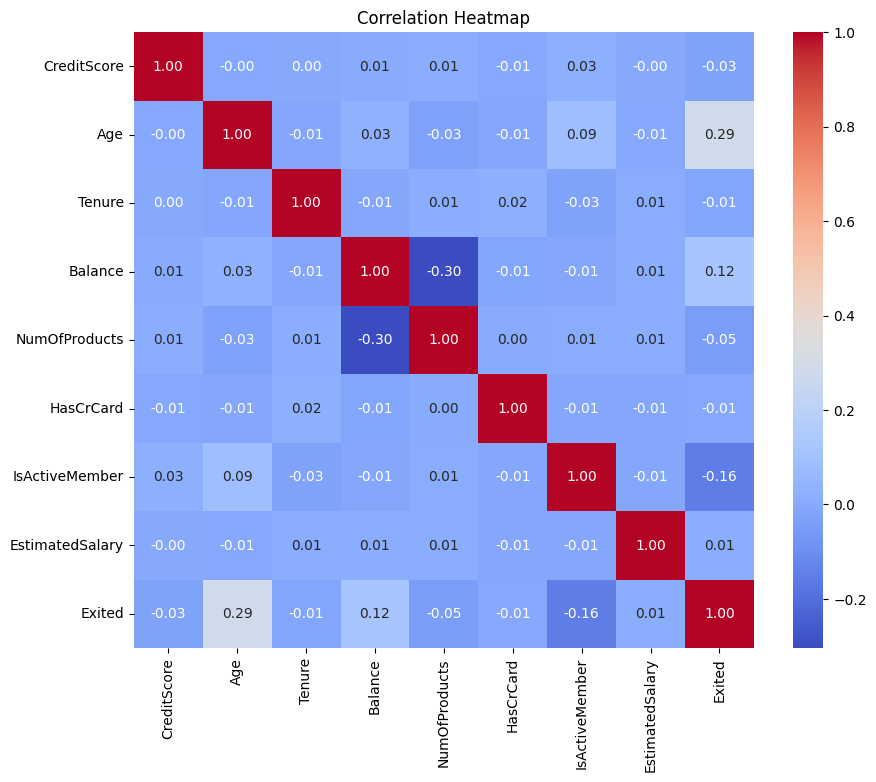

In [25]:
plt.figure(figsize=(10,8))
corr_matrix = df.drop(["RowNumber", "CustomerId"], axis=1).corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

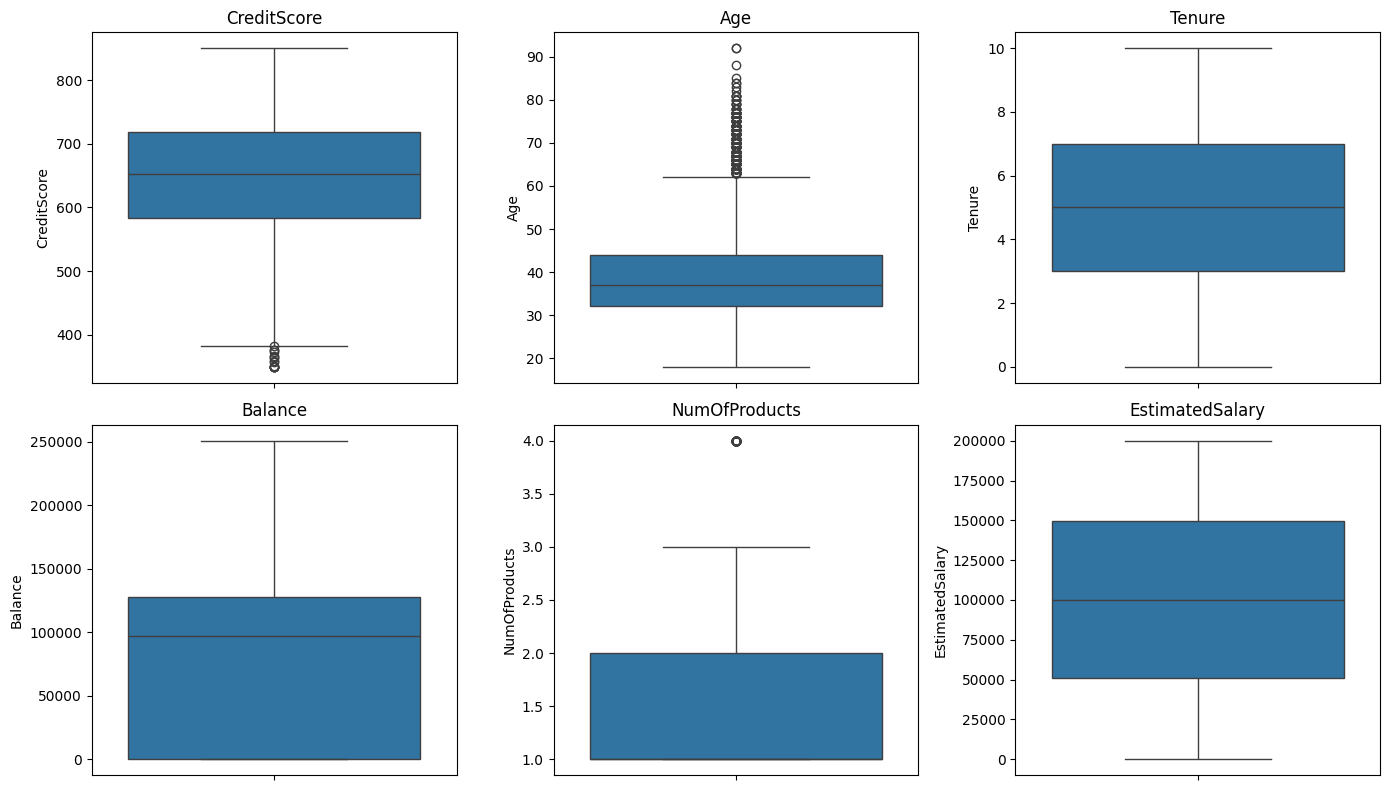

In [26]:
plt.figure(figsize=(14,8))

for i, col in enumerate(["CreditScore","Age","Tenure","Balance","NumOfProducts","EstimatedSalary"], 1):
    plt.subplot(2,3,i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

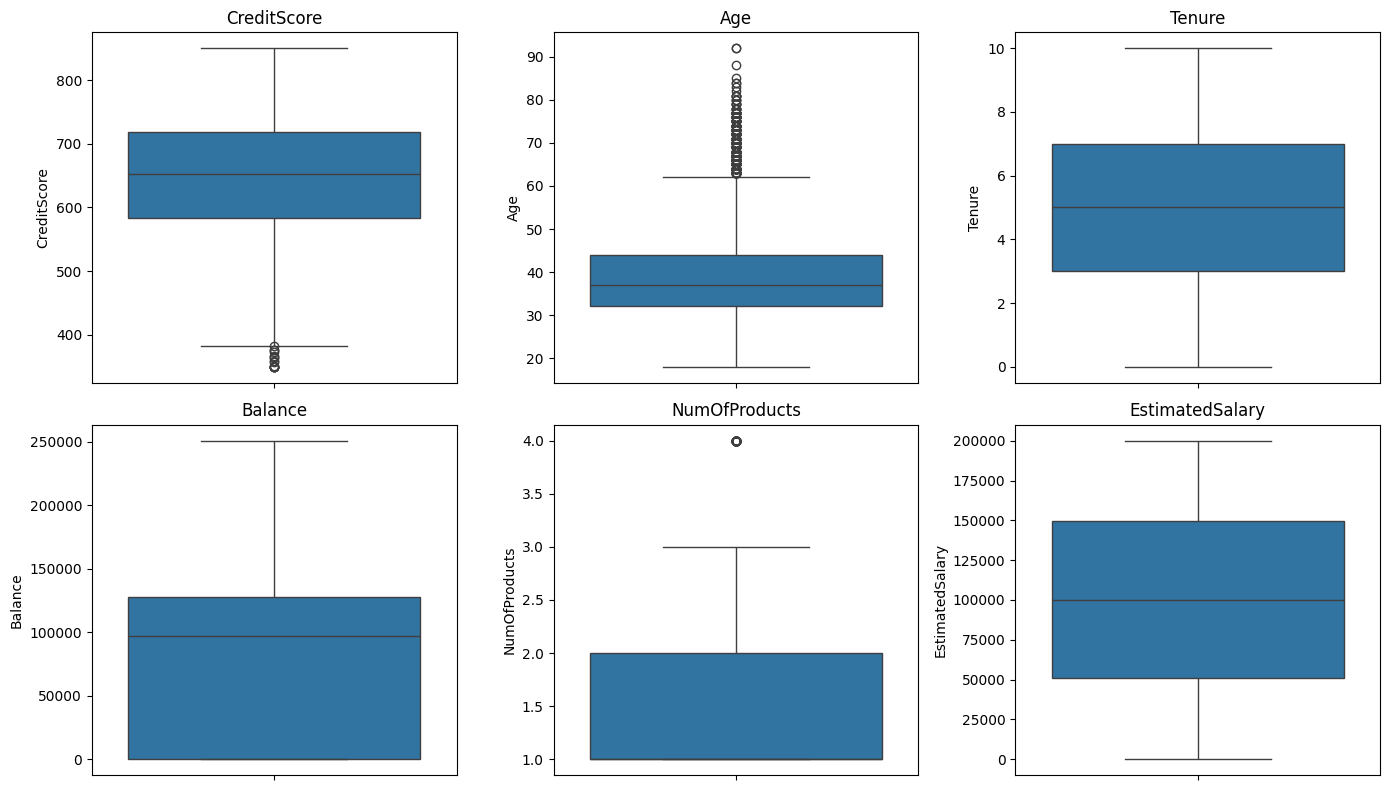

In [27]:
plt.figure(figsize=(14,8))

for i, col in enumerate(["CreditScore","Age","Tenure","Balance","NumOfProducts","EstimatedSalary"], 1):
    plt.subplot(2,3,i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [28]:
# Drop unnecessary columns
df = df.drop(["RowNumber", "CustomerId", "Surname"], axis=1)

# Feature engineering: create zero balance indicator
df["ZeroBalance"] = (df["Balance"] == 0).astype(int)

# Encode categorical variables
df = pd.get_dummies(df, drop_first=True)

# Convert boolean columns to integer
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,ZeroBalance,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,1,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,0,1,0


In [29]:
df.skew(numeric_only=True)

,0
CreditScore,-0.071607
Age,1.011320
Tenure,0.010991
Balance,-0.141109
NumOfProducts,0.745568
HasCrCard,-0.901812
IsActiveMember,-0.060437
EstimatedSalary,0.002085
Exited,1.471611
ZeroBalance,0.575746


In [30]:
# Check skewness before transformation
continuous_cols = ["CreditScore", "Age", "Tenure", "Balance", "EstimatedSalary"]

print(df[continuous_cols].skew())

CreditScore       -0.071607
Age                1.011320
Tenure             0.010991
Balance           -0.141109
EstimatedSalary    0.002085
dtype: float64


In [31]:
# Apply log transformation to reduce skewness in Age
df["Age"] = np.log1p(df["Age"])

In [32]:
# Check skewness after transformation
print(df[continuous_cols].skew())

CreditScore       -0.071607
Age                0.203360
Tenure             0.010991
Balance           -0.141109
EstimatedSalary    0.002085
dtype: float64


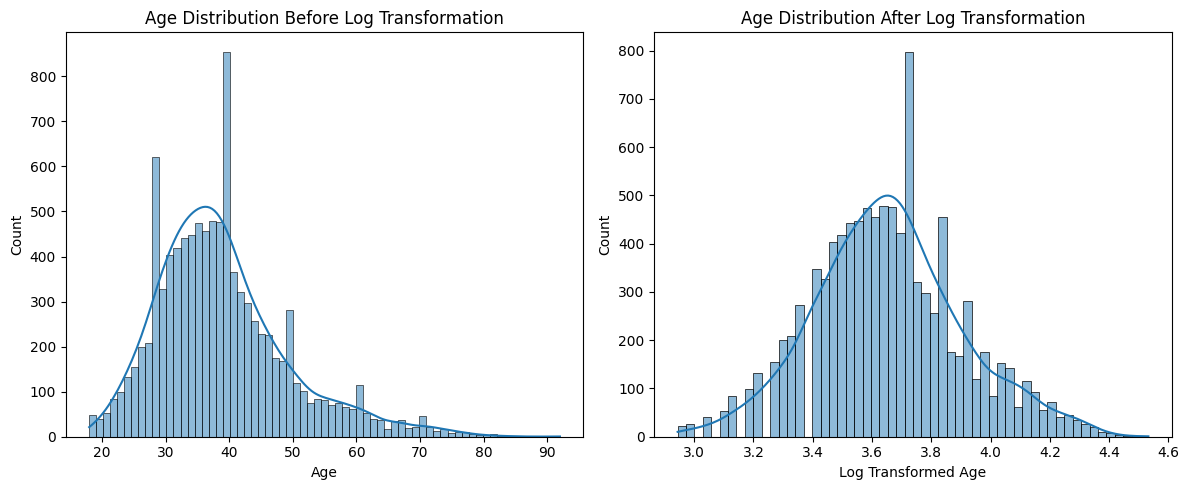

In [33]:
# Compare Age distribution before and after log transformation
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(np.expm1(df["Age"]), kde=True)
plt.title("Age Distribution Before Log Transformation")
plt.xlabel("Age")

plt.subplot(1,2,2)
sns.histplot(df["Age"], kde=True)
plt.title("Age Distribution After Log Transformation")
plt.xlabel("Log Transformed Age")

plt.tight_layout()
plt.show()

In [34]:
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,ZeroBalance,Geography_Germany,Geography_Spain,Gender_Male
0,619,3.761200,2,0.00,1,1,1,101348.88,1,1,0,0,0
1,608,3.737670,1,83807.86,1,0,1,112542.58,0,0,0,1,0
2,502,3.761200,8,159660.80,3,1,0,113931.57,1,0,0,0,0
3,699,3.688879,1,0.00,2,0,0,93826.63,0,1,0,0,0
4,850,3.784190,2,125510.82,1,1,1,79084.10,0,0,0,1,0


In [35]:
# Feature engineering
df["BalanceSalaryRatio"] = df["Balance"] / (df["EstimatedSalary"] + 1)
df["ProductsPerTenure"] = df["NumOfProducts"] / (df["Tenure"] + 1)

In [36]:
# Features and target
X = df.drop("Exited", axis=1)
y = df["Exited"]

In [37]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [38]:
# Feature scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [39]:
# Handle class imbalance (manual stronger weighting)

class_weights = {
    0: 1.0,
    1: 3.0
}

print("Class Weights:", class_weights)

Class Weights: {0: 1.0, 1: 3.0}


In [40]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(8000, 14)
(2000, 14)
(8000,)
(2000,)


In [41]:
#	Build Deep Learning model using ANN with multiple hidden layers.

In [42]:
ann_model = Sequential([
    Input(shape=(14,)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

ann_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

ann_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,585 (14.00 KB)

 Trainable params: 3,585 (14.00 KB)

 Non-trainable params: 0 (0.00 B)

In [43]:
history = ann_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    class_weight=class_weights,
    verbose=1
)

Epoch 1/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.7783 - loss: 0.8575 - val_accuracy: 0.7212 - val_loss: 0.5295
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7772 - loss: 0.7101 - val_accuracy: 0.8112 - val_loss: 0.4129
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7945 - loss: 0.6667 - val_accuracy: 0.7925 - val_loss: 0.4385
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8042 - loss: 0.6487 - val_accuracy: 0.7975 - val_loss: 0.4272
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8094 - loss: 0.6381 - val_accuracy: 0.8306 - val_loss: 0.3856
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8153 - loss: 0.6277 - val_accuracy: 0.8025 - val_loss: 0.4231
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8147 - loss: 0.6187 - val_accuracy: 0.8363 - val_loss: 0.3861
Epoch 8/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8214 - loss: 0.6149 - val_accuracy: 0.

In [44]:
test_loss, test_acc = ann_model.evaluate(X_test, y_test)
print("Baseline ANN Accuracy:", test_acc)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8020 - loss: 0.4812
Baseline ANN Accuracy: 0.8019999861717224


In [45]:
#Apply the dropout regularization and early stopping techniques to improve model performance.
#Use the modelCheckpoint also to store the parameters after each epoch.

In [46]:
better_model = Sequential([
    Input(shape=(14,)),

    Dense(256, activation="relu"),
    BatchNormalization(),
    Dropout(0.2),

    Dense(128, activation="relu"),
    BatchNormalization(),
    Dropout(0.2),

    Dense(64, activation="relu"),
    BatchNormalization(),

    Dense(32, activation="relu"),

    Dense(1, activation="sigmoid")
])

optimizer = Adam(learning_rate=0.001)

better_model.compile(
    optimizer=optimizer,
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

better_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 256)            │         3,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48,897 (191.00 KB)

 Trainable params: 48,001 (187.50 KB)

 Non-trainable params: 896 (3.50 KB)

In [47]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_better_model.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

lr_scheduler = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1
)

In [48]:
history_better = better_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stop, checkpoint, lr_scheduler],
    verbose=1
)

Epoch 1/100
191/200 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6807 - loss: 0.8803
Epoch 1: val_loss improved from None to 0.41720, saving model to best_better_model.keras

Epoch 1: finished saving model to best_better_model.keras
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.7217 - loss: 0.8265 - val_accuracy: 0.8413 - val_loss: 0.4172 - learning_rate: 0.0010
Epoch 2/100
182/200 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7734 - loss: 0.7308
Epoch 2: val_loss improved from 0.41720 to 0.40369, saving model to best_better_model.keras

Epoch 2: finished saving model to best_better_model.keras
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7723 - loss: 0.7248 - val_accuracy: 0.8144 - val_loss: 0.4037 - learning_rate: 0.0010
Epoch 3/100
184/200 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7723 - loss: 0.7289
Epoch 3: val_loss did not improve from 0.40369
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7811 - loss: 0.6984 - val_accuracy: 0.8087 - val_loss: 0

In [49]:
test_loss_better, test_acc_better = better_model.evaluate(X_test, y_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8240 - loss: 0.4001


In [50]:
# Compare baseline vs improved ANN

print("Baseline ANN Accuracy:", test_acc)
print("Improved ANN Accuracy:", test_acc_better)

improvement = (test_acc_better - test_acc) * 100
print("Accuracy Improvement:", round(improvement, 2), "%")

if test_acc_better > test_acc:
    print("Improved ANN model selected as the best model.")
else:
    print("Baseline ANN model selected as the best model.")

Baseline ANN Accuracy: 0.8019999861717224
Improved ANN Accuracy: 0.8240000009536743
Accuracy Improvement: 2.2 %
Improved ANN model selected as the best model.


In [51]:
# KerasTuner model

In [52]:
def build_model(hp):
    model = Sequential()

    model.add(Input(shape=(14,)))

    # First hidden layer
    model.add(Dense(
        units=hp.Int('units_1', min_value=32, max_value=256, step=32),
        activation=hp.Choice('activation_1', ['relu', 'tanh'])
    ))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Float('dropout_1', 0.1, 0.5, step=0.1)))

    # Second hidden layer
    model.add(Dense(
        units=hp.Int('units_2', min_value=16, max_value=128, step=16),
        activation=hp.Choice('activation_2', ['relu', 'tanh'])
    ))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Float('dropout_2', 0.1, 0.5, step=0.1)))

    # Optional third hidden layer
    if hp.Boolean("third_layer"):
        model.add(Dense(
            units=hp.Int('units_3', min_value=16, max_value=64, step=16),
            activation=hp.Choice('activation_3', ['relu', 'tanh'])
        ))

    model.add(Dense(1, activation='sigmoid'))

    optimizer = hp.Choice('optimizer', ['adam', 'rmsprop'])

    learning_rate = hp.Choice('learning_rate', [0.001, 0.0005, 0.0001])

    if optimizer == 'adam':
        opt = Adam(learning_rate=learning_rate)
    else:
        opt = RMSprop(learning_rate=learning_rate)

    model.compile(
        optimizer=opt,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [53]:
#Define tuner
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=40,
    executions_per_trial=1,
    directory='keras_tuner_dir',
    project_name='bank_churn_tuning',
    overwrite=True
)


#Early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

In [54]:
#Start tuning
tuner.search(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

Trial 40 Complete [00h 00m 21s]
val_accuracy: 0.8106250166893005

Best val_accuracy So Far: 0.8512499928474426
Total elapsed time: 00h 25m 13s


In [55]:
#hyperparameters
best_hp = tuner.get_best_hyperparameters(1)[0]

print("Best Units Layer 1:", best_hp.get('units_1'))
print("Best Units Layer 2:", best_hp.get('units_2'))
print("Best Optimizer:", best_hp.get('optimizer'))
print("Best Learning Rate:", best_hp.get('learning_rate'))

Best Units Layer 1: 224
Best Units Layer 2: 112
Best Optimizer: rmsprop
Best Learning Rate: 0.001


In [56]:
best_model = tuner.get_best_models(num_models=1)[0]
test_loss_tuned, test_acc_tuned = best_model.evaluate(X_test, y_test)

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas the saved optimizer has 12 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8325 - loss: 0.3919


In [57]:
# Compare all models and select final best model
best_accuracy = max(test_acc, test_acc_better, test_acc_tuned)

print("Baseline ANN Accuracy:", test_acc)
print("Improved ANN Accuracy:", test_acc_better)
print("Tuned ANN Accuracy:", test_acc_tuned)

if best_accuracy == test_acc_better:
    print("Improved ANN model selected as final best model.")
elif best_accuracy == test_acc_tuned:
    print("KerasTuner tuned ANN selected as final best model.")
else:
    print("Baseline ANN selected as final best model.")

Baseline ANN Accuracy: 0.8019999861717224
Improved ANN Accuracy: 0.8240000009536743
Tuned ANN Accuracy: 0.8324999809265137
KerasTuner tuned ANN selected as final best model.


63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
=== Default Threshold (0.5) ===
              precision    recall  f1-score   support

           0       0.91      0.88      0.89      1593
           1       0.58      0.65      0.61       407

    accuracy                           0.83      2000
   macro avg       0.74      0.76      0.75      2000
weighted avg       0.84      0.83      0.84      2000



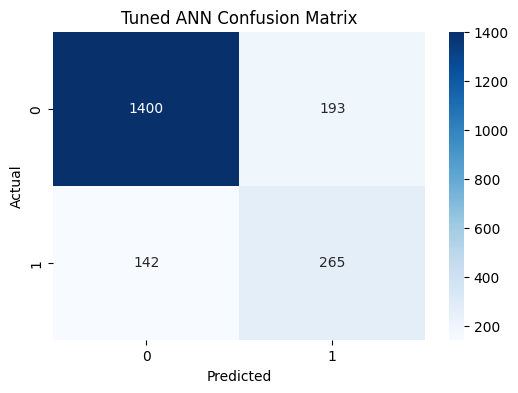

ROC AUC Score: 0.851142359616936


In [58]:
# Final best tuned model evaluation
y_pred_prob = best_model.predict(X_test)

# Default threshold
y_pred = (y_pred_prob > 0.5).astype(int)

print("=== Default Threshold (0.5) ===")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Tuned ANN Confusion Matrix")
plt.show()

print("ROC AUC Score:", roc_auc_score(y_test, y_pred_prob))

In [59]:
#Accident detection

In [60]:
with zipfile.ZipFile('accident-detection-from-cctv-footage.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/accident_dataset')

In [61]:
os.listdir('/content/accident_dataset')

['data']

In [62]:
from PIL import Image

from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Dense,
    Flatten,
    Dropout,
    BatchNormalization,
    GlobalAveragePooling2D,
    Input
)
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [63]:
dataset_path = '/content/accident_dataset'

for root, dirs, files in os.walk(dataset_path):
    print(root)

/content/accident_dataset
/content/accident_dataset/data
/content/accident_dataset/data/train
/content/accident_dataset/data/train/Accident
/content/accident_dataset/data/train/Non Accident
/content/accident_dataset/data/val
/content/accident_dataset/data/val/Accident
/content/accident_dataset/data/val/Non Accident
/content/accident_dataset/data/test
/content/accident_dataset/data/test/Accident
/content/accident_dataset/data/test/Non Accident


In [64]:
train_path = '/content/accident_dataset/data/train'
val_path = '/content/accident_dataset/data/val'
test_path = '/content/accident_dataset/data/test'

In [65]:
test_folder = test_path

bad_files = []

for cls in os.listdir(test_folder):
    cls_path = os.path.join(test_folder, cls)

    for file in os.listdir(cls_path):
        file_path = os.path.join(cls_path, file)

        try:
            img = Image.open(file_path)
            img.verify()
        except:
            bad_files.append(file_path)

print("Bad files:", bad_files)

Bad files: ['/content/accident_dataset/data/test/Non Accident/Pictures - Shortcut.lnk']


In [66]:
bad_file = '/content/accident_dataset/data/test/Non Accident/Pictures - Shortcut.lnk'

if os.path.exists(bad_file):
    os.remove(bad_file)
    print("Bad file removed successfully")
else:
    print("File not found")

Bad file removed successfully


In [67]:
classes = ['Accident', 'Non Accident']

for cls in classes:
    train_count = len(os.listdir(os.path.join(train_path, cls)))
    val_count = len(os.listdir(os.path.join(val_path, cls)))
    test_count = len(os.listdir(os.path.join(test_path, cls)))

    print(f"{cls}:")
    print(f"Train: {train_count}")
    print(f"Validation: {val_count}")
    print(f"Test: {test_count}")
    print("-" * 30)

Accident:
Train: 369
Validation: 46
Test: 47
------------------------------
Non Accident:
Train: 422
Validation: 52
Test: 53
------------------------------


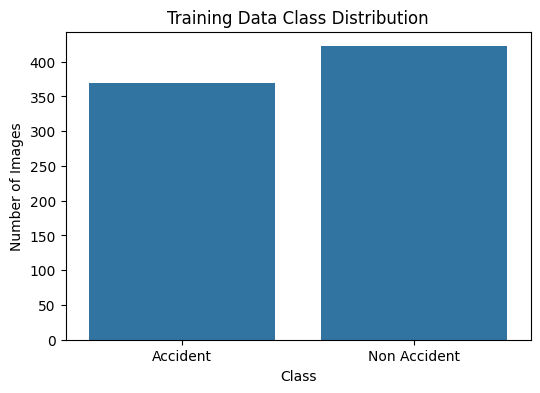

In [68]:
train_counts = [
    len(os.listdir(os.path.join(train_path, 'Accident'))),
    len(os.listdir(os.path.join(train_path, 'Non Accident')))
]

plt.figure(figsize=(6,4))
sns.barplot(x=['Accident', 'Non Accident'], y=train_counts)
plt.title('Training Data Class Distribution')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.show()

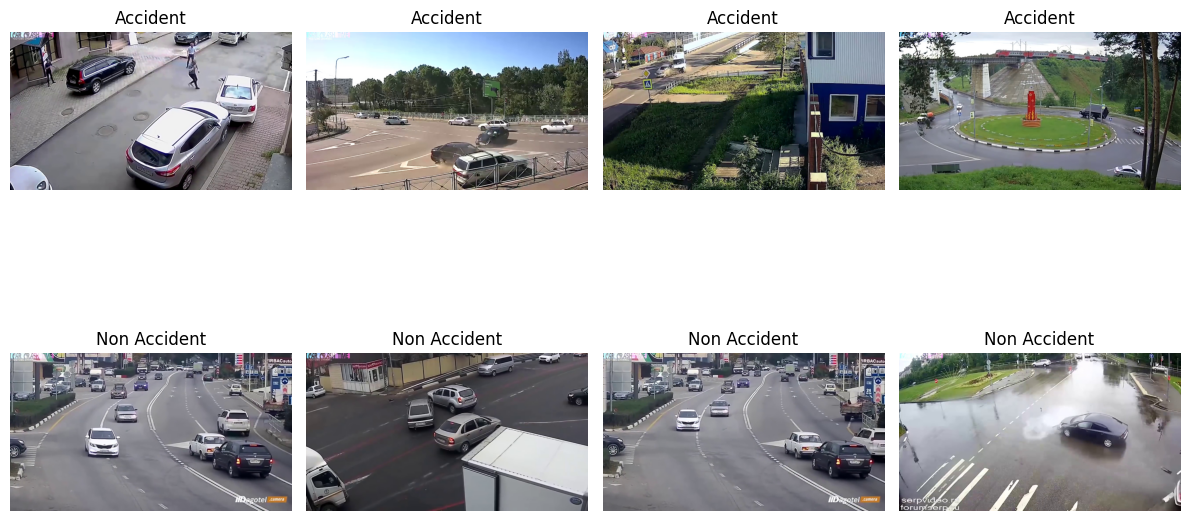

In [69]:
plt.figure(figsize=(12,8))

for i, cls in enumerate(classes):
    folder = os.path.join(train_path, cls)
    images = random.sample(os.listdir(folder), 4)

    for j, img_name in enumerate(images):
        img_path = os.path.join(folder, img_name)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(2,4,i*4+j+1)
        plt.imshow(img)
        plt.title(cls)
        plt.axis('off')

plt.tight_layout()
plt.show()

In [70]:
sample_img_path = os.path.join(
    train_path,
    'Accident',
    os.listdir(os.path.join(train_path, 'Accident'))[0]
)

img = cv2.imread(sample_img_path)

print("Image Shape:", img.shape)

Image Shape: (720, 1280, 3)


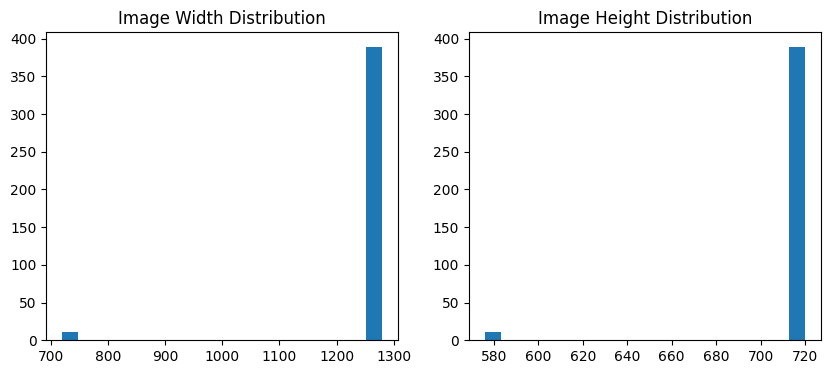

In [71]:
widths = []
heights = []

for cls in classes:
    folder = os.path.join(train_path, cls)

    for img_name in os.listdir(folder)[:200]:
        img_path = os.path.join(folder, img_name)
        img = cv2.imread(img_path)

        if img is not None:
            heights.append(img.shape[0])
            widths.append(img.shape[1])

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(widths, bins=20)
plt.title('Image Width Distribution')

plt.subplot(1,2,2)
plt.hist(heights, bins=20)
plt.title('Image Height Distribution')

plt.show()

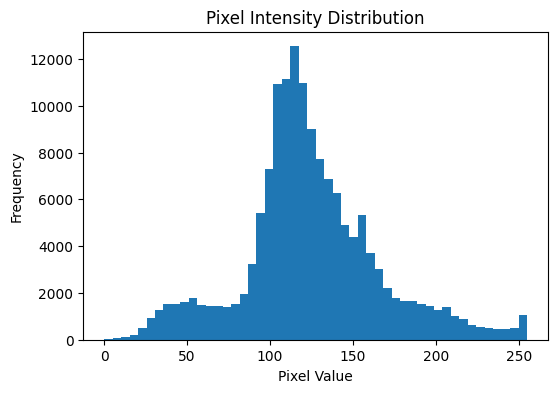

In [72]:
img_resized = cv2.resize(img, (224,224))

plt.figure(figsize=(6,4))
plt.hist(img_resized.ravel(), bins=50)
plt.title('Pixel Intensity Distribution')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.show()

In [73]:
img_size = (224, 224)
batch_size = 32

train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)


In [74]:
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary'
)

val_generator = val_datagen.flow_from_directory(
    val_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)

Found 791 images belonging to 2 classes.
Found 98 images belonging to 2 classes.
Found 100 images belonging to 2 classes.


In [75]:
cnn_model = Sequential([
    Input(shape=(224,224,3)),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

In [76]:
cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [77]:
cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [78]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [79]:
history_cnn = cnn_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stop, lr_scheduler]
)

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 22s 574ms/step - accuracy: 0.5424 - loss: 0.8685 - val_accuracy: 0.5714 - val_loss: 0.6702 - learning_rate: 0.0010
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 300ms/step - accuracy: 0.6296 - loss: 0.6508 - val_accuracy: 0.6939 - val_loss: 0.6044 - learning_rate: 0.0010
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 263ms/step - accuracy: 0.6802 - loss: 0.6162 - val_accuracy: 0.7143 - val_loss: 0.5411 - learning_rate: 0.0010
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step - accuracy: 0.7213 - loss: 0.5720
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 286ms/step - accuracy: 0.7295 - loss: 0.5638 - val_accuracy: 0.7653 - val_loss: 0.4856 - learning_rate: 0.0010
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 259ms/step - accuracy: 0.7370 - loss: 0.5384 - val_accuracy: 0.7347 - val_loss: 0.5301 - learning_rate: 5.0000e-04
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 289ms/step - accuracy: 0.7598 - loss: 0.489

In [80]:
test_loss_cnn, test_acc_cnn = cnn_model.evaluate(test_generator)

print("Scratch CNN Test Loss:", test_loss_cnn)
print("Scratch CNN Test Accuracy:", test_acc_cnn)

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 445ms/step - accuracy: 0.9400 - loss: 0.1901
Scratch CNN Test Loss: 0.19009776413440704
Scratch CNN Test Accuracy: 0.9399999976158142


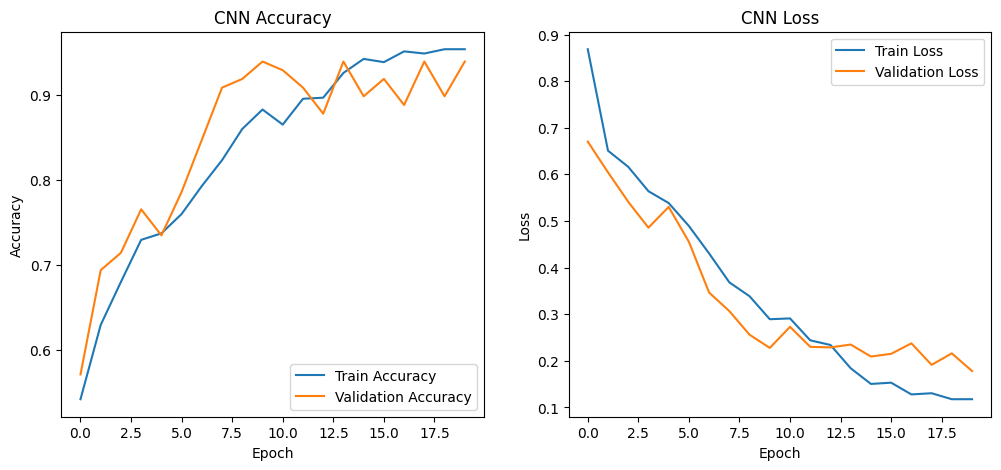

In [81]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_cnn.history['accuracy'], label='Train Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_cnn.history['loss'], label='Train Loss')
plt.plot(history_cnn.history['val_loss'], label='Validation Loss')
plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [82]:
y_pred = cnn_model.predict(test_generator)
y_pred = (y_pred > 0.5).astype(int)

print(classification_report(test_generator.classes, y_pred))

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 185ms/step
              precision    recall  f1-score   support

           0       0.94      0.94      0.94        47
           1       0.94      0.94      0.94        53

    accuracy                           0.94       100
   macro avg       0.94      0.94      0.94       100
weighted avg       0.94      0.94      0.94       100



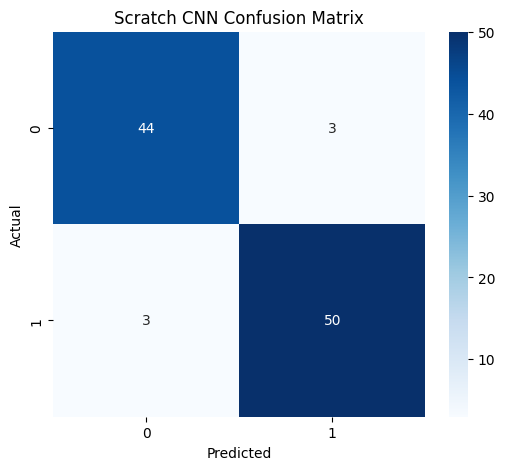

In [83]:
cm = confusion_matrix(test_generator.classes, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('Scratch CNN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [84]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

transfer_model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

transfer_model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='binary_crossentropy',
    metrics=['accuracy']
)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [85]:
transfer_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [86]:
early_stop_transfer = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [87]:
# ImageDataGenerators for transfer learning (no augmentation, only preprocessing)
train_datagen_transfer = ImageDataGenerator(
    preprocessing_function=preprocess_input
)
val_datagen_transfer = ImageDataGenerator(
    preprocessing_function=preprocess_input
)
test_datagen_transfer = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

# Generators for transfer learning using pre-defined transfer datagens
train_generator_transfer = train_datagen_transfer.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=batch_size,
    class_mode='binary'
)

val_generator_transfer = val_datagen_transfer.flow_from_directory(
    val_path,
    target_size=(224,224),
    batch_size=batch_size,
    class_mode='binary'
)

test_generator_transfer = test_datagen_transfer.flow_from_directory(
    test_path,
    target_size=(224,224),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)

print('Transfer learning data generators initialized.')

Found 791 images belonging to 2 classes.
Found 98 images belonging to 2 classes.
Found 100 images belonging to 2 classes.
Transfer learning data generators initialized.


In [88]:
history_transfer = transfer_model.fit(
    train_generator_transfer,
    validation_data=val_generator_transfer,
    epochs=15,
    callbacks=[early_stop_transfer]
)

Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 53s 1s/step - accuracy: 0.5954 - loss: 0.7247 - val_accuracy: 0.7653 - val_loss: 0.5232
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 283ms/step - accuracy: 0.7080 - loss: 0.5651 - val_accuracy: 0.7857 - val_loss: 0.4600
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 260ms/step - accuracy: 0.7699 - loss: 0.4792 - val_accuracy: 0.8163 - val_loss: 0.4120
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 271ms/step - accuracy: 0.8003 - loss: 0.4356 - val_accuracy: 0.8571 - val_loss: 0.3747
Epoch 5/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 273ms/step - accuracy: 0.8255 - loss: 0.3988 - val_accuracy: 0.8776 - val_loss: 0.3404
Epoch 6/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 255ms/step - accuracy: 0.8799 - loss: 0.3293 - val_accuracy: 0.8776 - val_loss: 0.2942
Epoch 7/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 279ms/step - accuracy: 0.8812 - loss: 0.3141 - val_accuracy: 0.9082 - val_loss: 0.3003
Epoch 8/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 254ms/step - accuracy: 0.8976 - loss: 0.2871 - val_accuracy: 0.88

In [89]:
transfer_test_loss, transfer_test_acc = transfer_model.evaluate(
    test_generator_transfer
)

print("Transfer Learning Test Accuracy:", transfer_test_acc)

4/4 ━━━━━━━━━━━━━━━━━━━━ 12s 4s/step - accuracy: 0.9000 - loss: 0.2150
Transfer Learning Test Accuracy: 0.8999999761581421


In [90]:
test_generator_transfer.reset()

transfer_pred_probs = transfer_model.predict(test_generator_transfer)
transfer_predictions = (transfer_pred_probs > 0.5).astype(int)

3/4 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step


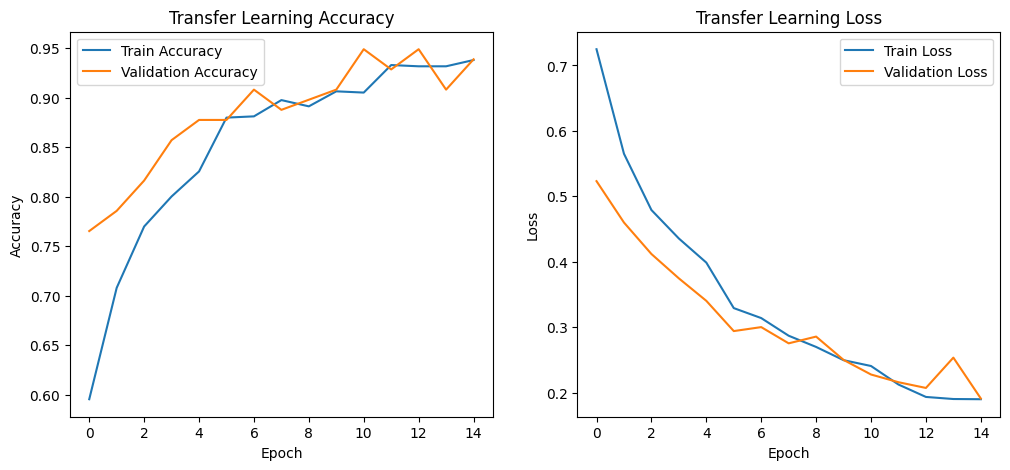

In [91]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_transfer.history['accuracy'], label='Train Accuracy')
plt.plot(history_transfer.history['val_accuracy'], label='Validation Accuracy')
plt.title('Transfer Learning Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_transfer.history['loss'], label='Train Loss')
plt.plot(history_transfer.history['val_loss'], label='Validation Loss')
plt.title('Transfer Learning Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [92]:
print(classification_report(
    test_generator_transfer.classes,
    transfer_predictions,
    target_names=['Accident', 'Non Accident']
))

              precision    recall  f1-score   support

    Accident       0.95      0.83      0.89        47
Non Accident       0.86      0.96      0.91        53

    accuracy                           0.90       100
   macro avg       0.91      0.90      0.90       100
weighted avg       0.91      0.90      0.90       100



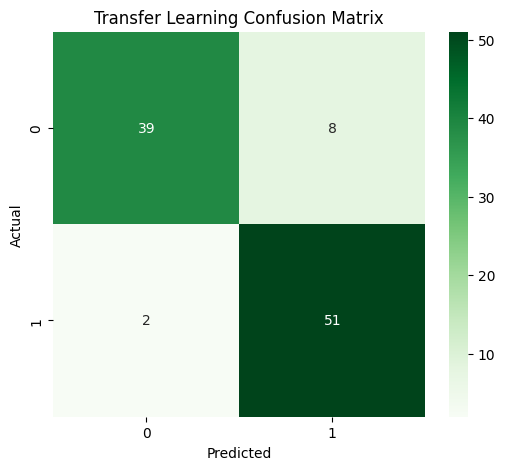

In [93]:
cm_transfer = confusion_matrix(
    test_generator_transfer.classes,
    transfer_predictions
)

plt.figure(figsize=(6,5))
sns.heatmap(cm_transfer, annot=True, fmt='d', cmap='Greens')
plt.title('Transfer Learning Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [94]:
train_datagen_aug = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    zoom_range=0.10,
    width_shift_range=0.08,
    height_shift_range=0.08,
    horizontal_flip=True
)

val_datagen_aug = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

test_datagen_aug = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [95]:
train_generator_aug = train_datagen_aug.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

val_generator_aug = val_datagen_aug.flow_from_directory(
    val_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

test_generator_aug = test_datagen_aug.flow_from_directory(
    test_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 791 images belonging to 2 classes.
Found 98 images belonging to 2 classes.
Found 100 images belonging to 2 classes.


In [96]:
base_model_aug = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model_aug.trainable = False

In [97]:
aug_model = Sequential([
    base_model_aug,
    GlobalAveragePooling2D(),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

In [98]:
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=6,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7
)

aug_model.compile(
    optimizer=Adam(learning_rate=3e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_aug = aug_model.fit(
    train_generator_aug,
    validation_data=val_generator_aug,
    epochs=20,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.5398 - loss: 0.7518 - val_accuracy: 0.6122 - val_loss: 0.6474 - learning_rate: 3.0000e-04
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 15s 590ms/step - accuracy: 0.6789 - loss: 0.6025 - val_accuracy: 0.7041 - val_loss: 0.5733 - learning_rate: 3.0000e-04
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 15s 589ms/step - accuracy: 0.7105 - loss: 0.5534 - val_accuracy: 0.7653 - val_loss: 0.5292 - learning_rate: 3.0000e-04
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 15s 594ms/step - accuracy: 0.7269 - loss: 0.5201 - val_accuracy: 0.7041 - val_loss: 0.5171 - learning_rate: 3.0000e-04
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 15s 590ms/step - accuracy: 0.7598 - loss: 0.5012 - val_accuracy: 0.7449 - val_loss: 0.4922 - learning_rate: 3.0000e-04
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 15s 601ms/step - accuracy: 0.7750 - loss: 0.4724 - val_accuracy: 0.7551 - val_loss: 0.4687 - learning_rate: 3.0000e-04
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 15s 586ms/step - accura

In [99]:
aug_test_loss, aug_test_acc = aug_model.evaluate(test_generator_aug)
print("Augmented Transfer Learning Test Accuracy:", aug_test_acc)

4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.8800 - loss: 0.3375
Augmented Transfer Learning Test Accuracy: 0.8799999952316284


In [100]:
test_generator_aug.reset()

aug_pred_probs = aug_model.predict(test_generator_aug)
aug_predictions = (aug_pred_probs > 0.5).astype(int).flatten()

4/4 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step


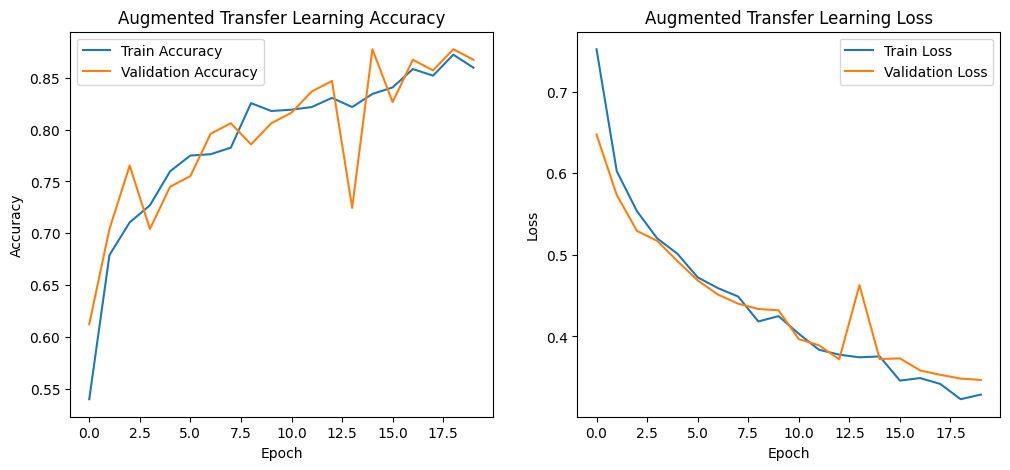

In [101]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_aug.history['accuracy'], label='Train Accuracy')
plt.plot(history_aug.history['val_accuracy'], label='Validation Accuracy')
plt.title('Augmented Transfer Learning Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_aug.history['loss'], label='Train Loss')
plt.plot(history_aug.history['val_loss'], label='Validation Loss')
plt.title('Augmented Transfer Learning Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

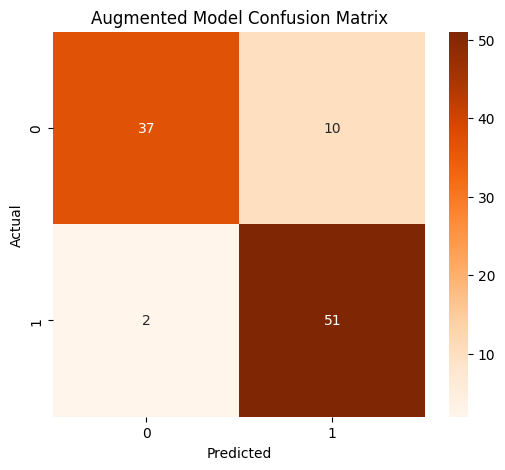

In [102]:
cm_aug = confusion_matrix(
    test_generator_aug.classes,
    aug_predictions
)

plt.figure(figsize=(6,5))
sns.heatmap(cm_aug, annot=True, fmt='d', cmap='Oranges')
plt.title('Augmented Model Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [103]:
print(classification_report(
    test_generator_aug.classes,
    aug_predictions,
    target_names=['Accident', 'Non Accident']
))

              precision    recall  f1-score   support

    Accident       0.95      0.79      0.86        47
Non Accident       0.84      0.96      0.89        53

    accuracy                           0.88       100
   macro avg       0.89      0.87      0.88       100
weighted avg       0.89      0.88      0.88       100



In [104]:
results = pd.DataFrame({
    'Model': [
        'Custom CNN',
        'Transfer Learning (MobileNetV2)',
        'Transfer Learning + Data Augmentation'
    ],
    'Training Accuracy': [
        max(history_cnn.history['accuracy']),
        max(history_transfer.history['accuracy']),
        max(history_aug.history['accuracy'])
    ],
    'Test Accuracy': [
        test_acc_cnn,
        transfer_test_acc,
        aug_test_acc
    ]
})

print(results)

                                   Model  Training Accuracy  Test Accuracy
0                             Custom CNN           0.953224           0.94
1        Transfer Learning (MobileNetV2)           0.938053           0.90
2  Transfer Learning + Data Augmentation           0.872313           0.88


<Figure size 1000x600 with 0 Axes>

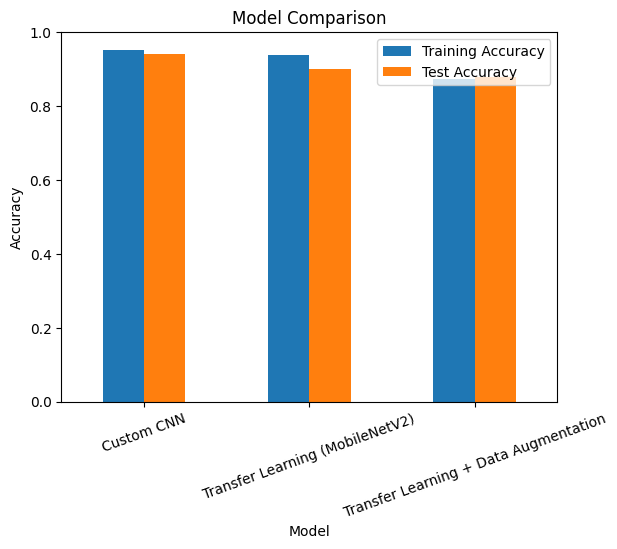

In [105]:
plt.figure(figsize=(10,6))

results.set_index('Model')[['Training Accuracy', 'Test Accuracy']].plot(kind='bar')

plt.title('Model Comparison')
plt.ylabel('Accuracy')
plt.xticks(rotation=20)
plt.show()